# Self-Refining Code Generation — Progress from M1 to Cluster Experiments

This notebook is the running presentation summary for supervisor meetings. It is updated after each milestone; full technical evidence remains in `experiments/results/` and `docs/validation/`.

- **M1:** end-to-end mock pipeline and sandboxed execution complete
- **M2:** real-model single-pass development baselines complete
- **M3:** iterative template-feedback refinement complete
- **M4:** compute-matched best-of-five fairness baseline complete
- **M5:** template, trace, and hybrid feedback comparison complete
- **M6:** exact paired tests and bootstrap confidence intervals complete
- **M7:** eight-configuration Tier 1 local matrix complete on HumanEval and corrected MBPP

> **Scope:** Sections M2–M7 preserve the historical local Qwen `Q4_K_M` development record. The cluster sections added below contain the frozen full-precision Tier 1 reporting results, precision/backend comparisons, forced-iteration analysis, and the current Tier 2 status.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "experiments" / "results").is_dir():
    ROOT = ROOT.parent
RESULTS = ROOT / "experiments" / "results"
VALIDATION = ROOT / "docs" / "validation"
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from analysis.results import load_paired_outcomes, load_pass_fail_vector
from analysis.stats import bootstrap_pass_at_1, mcnemar_exact
assert RESULTS.is_dir(), "Run this notebook from the repository or notebooks directory"

RUNS = {
    "single": {
        "HumanEval-Dev": RESULTS / "20260713T131758.814615Z_m2_qwen_ollama_zero_shot_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T200916.764652Z_m2_qwen_ollama_zero_shot_mbpp_dev",
    },
    "refined": {
        "HumanEval-Dev": RESULTS / "20260713T191841.745630Z_m3_qwen_ollama_template_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T201936.683659Z_m3_qwen_ollama_template_refinement_mbpp_dev",
    },
    "bo5": {
        "HumanEval-Dev": RESULTS / "20260713T193041.127180Z_m4_qwen_ollama_best_of_5_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T201055.926372Z_m4_qwen_ollama_best_of_5_mbpp_dev",
    },
    "template": {
        "HumanEval-Dev": RESULTS / "20260713T222148.461537Z_m5_qwen_ollama_template_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T222826.453953Z_m5_qwen_ollama_template_refinement_mbpp_dev",
    },
    "trace": {
        "HumanEval-Dev": RESULTS / "20260713T222522.003946Z_m5_qwen_ollama_trace_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T223141.925579Z_m5_qwen_ollama_trace_refinement_mbpp_dev",
    },
    "hybrid": {
        "HumanEval-Dev": RESULTS / "20260713T222718.512169Z_m5_qwen_ollama_hybrid_refinement_humaneval_dev",
        "MBPP-Dev": RESULTS / "20260713T223538.251373Z_m5_qwen_ollama_hybrid_refinement_mbpp_dev",
    },
}
INVALID_MBPP = RESULTS / "20260713T194903.209391Z_m2_qwen_ollama_zero_shot_mbpp_dev"

for group in RUNS.values():
    for run in group.values():
        assert (run / "summary.csv").is_file(), f"Missing result artifact: {run}"

def summary_row(run):
    frame = pd.read_csv(run / "summary.csv")
    assert len(frame) == 1
    return frame.iloc[0]

def problem_record(run, task_id):
    filename = task_id.replace("/", "_") + ".json"
    return json.loads((run / "problems" / filename).read_text())

def label_bars(ax, digits=2):
    for container in ax.containers:
        ax.bar_label(container, fmt=f"%.{digits}f", padding=3, fontsize=9)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#4472C4", "#70AD47", "#ED7D31", "#7030A0"]
pd.set_option("display.precision", 3)

## M2 — Single-pass baseline

,pass@1_single
Benchmark,
HumanEval-Dev,0.85
MBPP-Dev,0.76


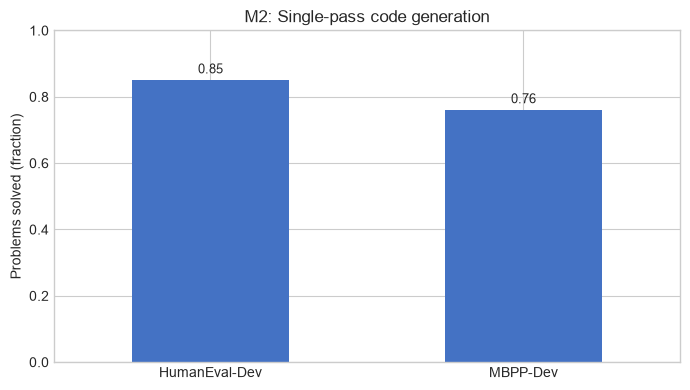

In [2]:
m2 = pd.DataFrame(
    [
        {"Benchmark": benchmark, "pass@1_single": summary_row(run)["value"]}
        for benchmark, run in RUNS["single"].items()
    ]
).set_index("Benchmark")
display(m2.style.format("{:.2f}").set_caption("M2 measured dev-set baseline"))
ax = m2.plot.bar(color=COLORS[0], figsize=(7, 4), legend=False, ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M2: Single-pass code generation")
ax.tick_params(axis="x", rotation=0)
label_bars(ax)
plt.tight_layout()
plt.show()

## M3 — Iterative refinement

Configuration,Single pass,Template refinement
Benchmark,,
HumanEval-Dev,0.85,0.95
MBPP-Dev,0.76,0.78


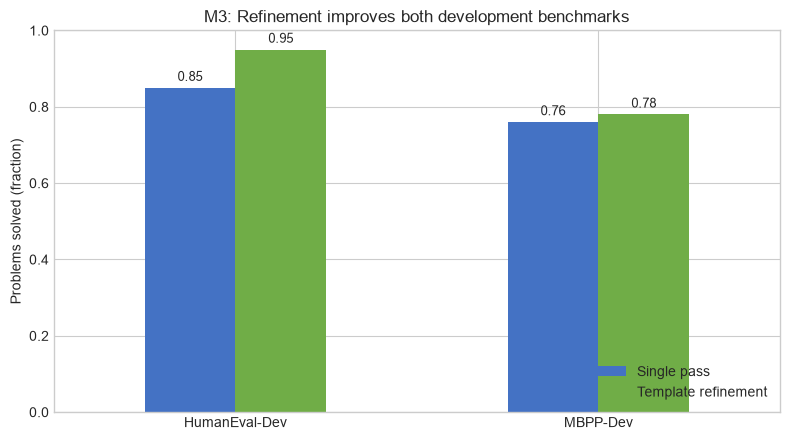

<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'><b>HumanEval/46:</b> feedback correctly exposed the output mismatch, but the model repeated its code and stopped by <b>oscillation</b> after <b>2</b> iterations. Better evidence does not guarantee correction.</div>

In [3]:
m3_rows = []
for benchmark in RUNS["single"]:
    m3_rows.extend([
        {"Benchmark": benchmark, "Configuration": "Single pass", "Score": summary_row(RUNS["single"][benchmark])["value"]},
        {"Benchmark": benchmark, "Configuration": "Template refinement", "Score": summary_row(RUNS["refined"][benchmark])["value"]},
    ])
m3 = pd.DataFrame(m3_rows).pivot(index="Benchmark", columns="Configuration", values="Score")
m3 = m3[["Single pass", "Template refinement"]]
display(m3.style.format("{:.2f}").set_caption("M3: single pass versus iterative refinement"))
ax = m3.plot.bar(color=COLORS[:2], figsize=(8, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M3: Refinement improves both development benchmarks")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

he46 = problem_record(RUNS["refined"]["HumanEval-Dev"], "HumanEval/46")
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'>"
    f"<b>HumanEval/46:</b> feedback correctly exposed the output mismatch, but the model repeated its code and stopped by "
    f"<b>{he46['convergence_reason']}</b> after <b>{len(he46['iterations'])}</b> iterations. Better evidence does not guarantee correction.</div>"
))

## M4 — Fairness baseline and compute cost

Configuration,Single pass,Best of 5,Refinement
Benchmark,,,
HumanEval-Dev,0.85,0.95,0.95
MBPP-Dev,0.76,0.80,0.78


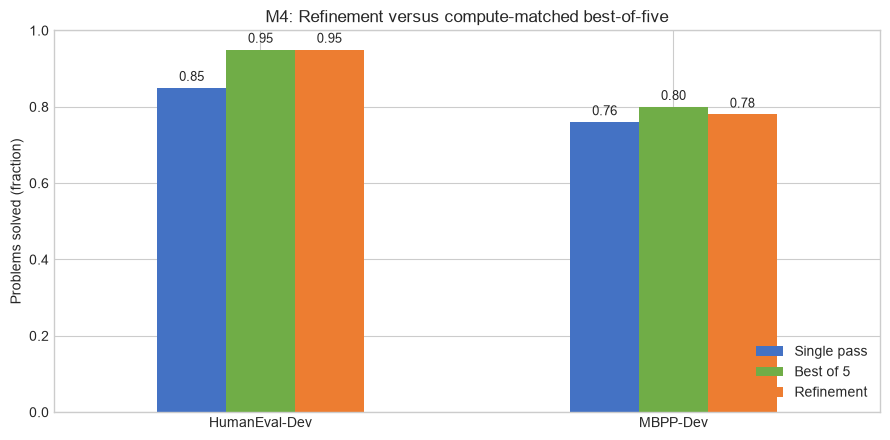

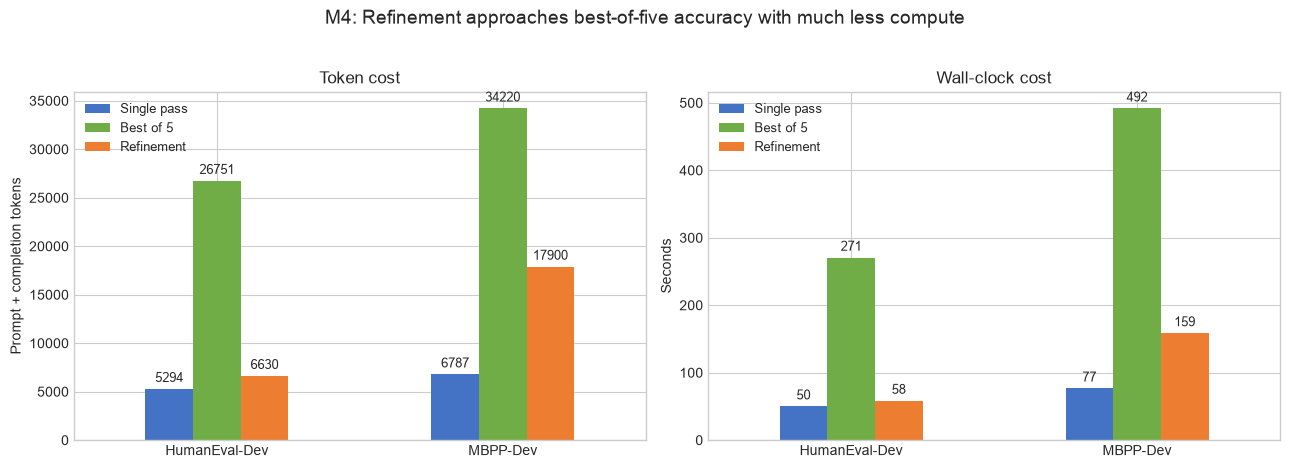

<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'><b>MBPP entry-point bug:</b> the original prompt omitted the required function signature. We caught it because <b>45/47</b> failures were <code>NameError</code> failures—not logic errors. The prompt contract was corrected and every M4+ result shown here uses post-fix artifacts.</div>

In [4]:
m4_rows = []
config_runs = [("Single pass", "single"), ("Best of 5", "bo5"), ("Refinement", "refined")]
for benchmark in RUNS["single"]:
    for label, key in config_runs:
        row = summary_row(RUNS[key][benchmark])
        m4_rows.append({
            "Benchmark": benchmark,
            "Configuration": label,
            "Score": row["value"],
            "Tokens": row["prompt_tokens"] + row["completion_tokens"],
            "Wall-clock seconds": row["wall_clock_seconds"],
        })
m4_long = pd.DataFrame(m4_rows)
m4 = m4_long.pivot(index="Benchmark", columns="Configuration", values="Score")[["Single pass", "Best of 5", "Refinement"]]
display(m4.style.format("{:.2f}").set_caption("M4: accuracy under the three required configurations"))
ax = m4.plot.bar(color=COLORS, figsize=(9, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M4: Refinement versus compute-matched best-of-five")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, measure, title, ylabel in [
    (axes[0], "Tokens", "Token cost", "Prompt + completion tokens"),
    (axes[1], "Wall-clock seconds", "Wall-clock cost", "Seconds"),
]:
    cost = m4_long.pivot(index="Benchmark", columns="Configuration", values=measure)[["Single pass", "Best of 5", "Refinement"]]
    cost.plot.bar(ax=ax, color=COLORS)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", fontsize=9)
    label_bars(ax, digits=0)
fig.suptitle("M4: Refinement approaches best-of-five accuracy with much less compute", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

invalid_records = [json.loads(path.read_text()) for path in (INVALID_MBPP / "problems").glob("*.json")]
invalid_failures = [record for record in invalid_records if not record["passed"]]
name_error_failures = sum(
    any(test["exception_type"] == "NameError" for test in record["iterations"][0]["execution"]["tests"])
    for record in invalid_failures
)
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'>"
    f"<b>MBPP entry-point bug:</b> the original prompt omitted the required function signature. We caught it because "
    f"<b>{name_error_failures}/{len(invalid_failures)}</b> failures were <code>NameError</code> failures—not logic errors. "
    f"The prompt contract was corrected and every M4+ result shown here uses post-fix artifacts.</div>"
))

## M5 — Feedback strategy comparison

Strategy,Template,Trace,Hybrid
Benchmark,,,
HumanEval-Dev,0.95,0.90,0.90
MBPP-Dev,0.78,0.84,0.84


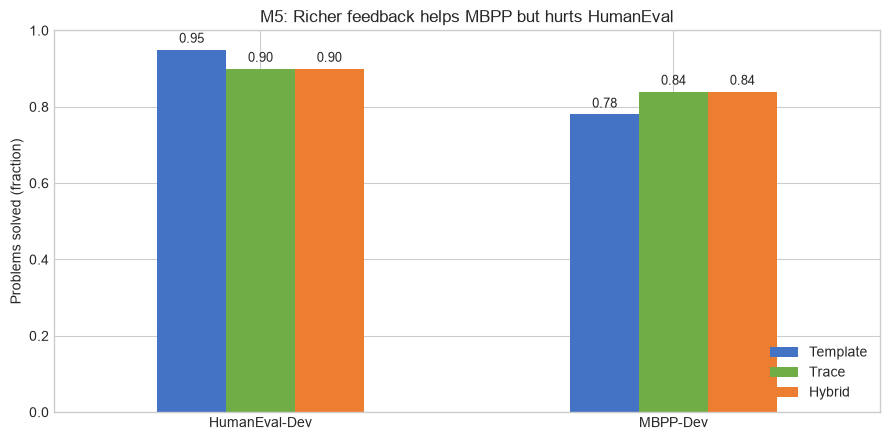

<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'><b>Genuine trade-off:</b> trace/hybrid improved MBPP from <b>0.78</b> to <b>0.84</b>, but HumanEval moved from <b>0.95</b> to <b>0.90</b>. This negative result is part of the finding, not something to smooth over.</div>

In [5]:
m5_rows = []
for benchmark in RUNS["template"]:
    for label, key in [("Template", "template"), ("Trace", "trace"), ("Hybrid", "hybrid")]:
        m5_rows.append({"Benchmark": benchmark, "Strategy": label, "Score": summary_row(RUNS[key][benchmark])["value"]})
m5 = pd.DataFrame(m5_rows).pivot(index="Benchmark", columns="Strategy", values="Score")[["Template", "Trace", "Hybrid"]]
display(m5.style.format("{:.2f}").set_caption("M5: pass@1_refined by feedback strategy"))
ax = m5.plot.bar(color=COLORS, figsize=(9, 4.5), ylim=(0, 1))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M5: Richer feedback helps MBPP but hurts HumanEval")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower right")
label_bars(ax)
plt.tight_layout()
plt.show()

he_template, he_trace = m5.loc["HumanEval-Dev", ["Template", "Trace"]]
mb_template, mb_trace = m5.loc["MBPP-Dev", ["Template", "Trace"]]
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'>"
    f"<b>Genuine trade-off:</b> trace/hybrid improved MBPP from <b>{mb_template:.2f}</b> to <b>{mb_trace:.2f}</b>, "
    f"but HumanEval moved from <b>{he_template:.2f}</b> to <b>{he_trace:.2f}</b>. This negative result is part of the finding, not something to smooth over.</div>"
))

## M6 — Statistical analysis on the development sets

M6 introduced exact two-sided McNemar tests for paired pass/fail outcomes and 10,000-resample problem-level bootstrap confidence intervals. The tables below read the committed M6 analysis artifact; they do not rerun a model or inspect benchmark source data.

At only 20 HumanEval-Dev and 50 MBPP-Dev problems, none of the planned paired comparisons reached α=0.05. This lack of evidence—together with wide bootstrap intervals—motivated M7's frozen full-scale runs.

In [6]:
m6_path = VALIDATION / "m6_dev_statistics.json"
assert m6_path.is_file(), f"Missing committed M6 artifact: {m6_path}"
m6_data = json.loads(m6_path.read_text(encoding="utf-8"))

m6_ci_rows = []
for item in m6_data["configurations"].values():
    ci = item["bootstrap_ci"]
    m6_ci_rows.append({
        "Benchmark": item["benchmark"],
        "Configuration": item["label"],
        "pass@1": ci["estimate"],
        "CI lower": ci["lower"],
        "CI upper": ci["upper"],
    })
m6_ci = pd.DataFrame(m6_ci_rows).sort_values(["Benchmark", "Configuration"])
display(
    m6_ci.style.format({
        "pass@1": "{:.2f}",
        "CI lower": "{:.2f}",
        "CI upper": "{:.2f}",
    }).set_caption("M6 dev-set bootstrap 95% confidence intervals (10,000 resamples)")
)

m6_test_rows = []
for item in m6_data["comparisons"].values():
    test = item["mcnemar"]
    m6_test_rows.append({
        "Benchmark": item["benchmark"],
        "Comparison": f"{item['first_label']} vs {item['second_label']}",
        "First only": test["first_only"],
        "Second only": test["second_only"],
        "Risk difference": test["paired_risk_difference"],
        "Exact p": test["p_value"],
        "Significant (α=0.05)": item["significant"],
    })
m6_tests = pd.DataFrame(m6_test_rows).sort_values(["Benchmark", "Comparison"])
display(
    m6_tests.style.format({
        "Risk difference": "{:+.3f}",
        "Exact p": "{:.3f}",
    }).set_caption("M6 exact two-sided McNemar comparisons")
)

assert not m6_tests["Significant (α=0.05)"].any()
display(Markdown(
    "<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'>"
    "<b>M6 conclusion:</b> no dev-set comparison was statistically significant. "
    "The dev splits supported engineering and case analysis, but were too small for "
    "strong headline inference; this directly motivated the full-scale M7 matrix.</div>"
))

,Benchmark,Configuration,pass@1,CI lower,CI upper
0,HumanEval-Dev,Best of 5,0.95,0.85,1.00
1,HumanEval-Dev,Hybrid feedback,0.90,0.75,1.00
4,HumanEval-Dev,M5 template feedback,0.95,0.85,1.00
3,HumanEval-Dev,Single pass,0.85,0.70,1.00
2,HumanEval-Dev,Template refinement,0.95,0.85,1.00
5,HumanEval-Dev,Trace feedback,0.90,0.75,1.00
6,MBPP-Dev,Best of 5,0.80,0.68,0.90
7,MBPP-Dev,Hybrid feedback,0.84,0.74,0.94
10,MBPP-Dev,M5 template feedback,0.78,0.66,0.88
9,MBPP-Dev,Single pass,0.76,0.64,0.88


,Benchmark,Comparison,First only,Second only,Risk difference,Exact p,Significant (α=0.05)
0,HumanEval-Dev,Hybrid feedback vs M5 template feedback,0,1,-0.050,1.000,False
1,HumanEval-Dev,Template refinement vs Best of 5,1,1,+0.000,1.000,False
2,HumanEval-Dev,Trace feedback vs M5 template feedback,0,1,-0.050,1.000,False
3,MBPP-Dev,Hybrid feedback vs M5 template feedback,3,0,+0.060,0.250,False
4,MBPP-Dev,Template refinement vs Best of 5,1,2,-0.020,1.000,False
5,MBPP-Dev,Trace feedback vs M5 template feedback,3,0,+0.060,0.250,False


<div style='padding:12px;border-left:5px solid #ED7D31;background:#fff4e8'><b>M6 conclusion:</b> no dev-set comparison was statistically significant. The dev splits supported engineering and case analysis, but were too small for strong headline inference; this directly motivated the full-scale M7 matrix.</div>

## M7 — Full-scale Tier 1 local quantized-development matrix

M7 ran all eight frozen configurations: four strategies on HumanEval-164 and corrected MBPP-427. Every value below is derived from committed run summaries and per-problem JSON. “Fixed k=5 (ever solved)” is the protocol metric—solved at any iteration—while “final-only” is a diagnostic showing what would happen if only iteration 5 were retained.

Best-of-five always makes five independent calls per problem. Adaptive refinement stops according to the success-first convergence rules. Fixed-k always makes five sequential calls, even after success.

> **HumanEval feedback correction:** the adaptive and fixed-k entries below use the corrected compound-harness feedback runs (`15dc62a` and `c10e59e`). The correction left adaptive accuracy unchanged at 143/164, reduced fixed-k ever-solved from 144/164 to 143/164, and reduced fixed-k final-only from 140/164 to 138/164. Full provenance and paired flips are documented in `docs/validation/m7_humaneval_feedback_correction.md`.

,Benchmark,Strategy,Accuracy (ever solved),Final-only accuracy,Model calls,Solved,Problems
0,HumanEval-164,Single pass,0.8293,—,164,136,164
1,HumanEval-164,Best of 5,0.9146,—,820,150,164
2,HumanEval-164,Hybrid adaptive,0.8720,—,202,143,164
3,HumanEval-164,Hybrid fixed k=5,0.8720,0.8415,820,143,164
4,MBPP-427,Single pass,0.7283,—,427,311,427
5,MBPP-427,Best of 5,0.8033,—,2135,343,427
6,MBPP-427,Hybrid adaptive,0.8220,—,637,351,427
7,MBPP-427,Hybrid fixed k=5,0.8197,0.7892,2135,350,427


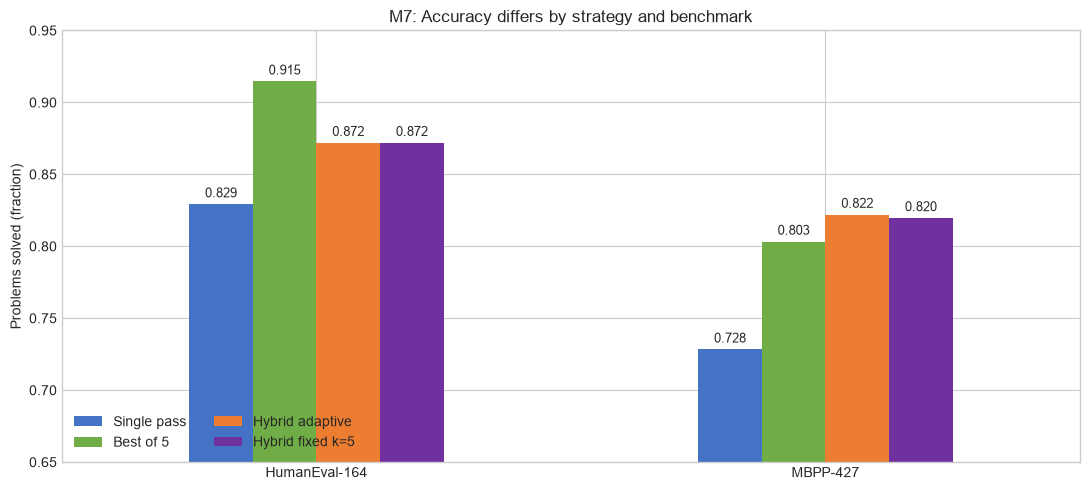

In [7]:
M7_RUNS = {
    "HumanEval-164": {
        "Single pass": RESULTS / "20260715T215247Z_m7_quantized_local_development_single_humaneval_full",
        "Best of 5": RESULTS / "20260716T225945.085688Z_m7_quantized_local_development_best_of_5_humaneval_full",
        "Hybrid adaptive": RESULTS / "20260723T191407.382508Z_m7_quantized_local_development_hybrid_refinement_adaptive_humaneval_full",
        "Hybrid fixed k=5": RESULTS / "20260724T151654.164295Z_m7_quantized_local_development_hybrid_refinement_fixed_humaneval_full",
    },
    "MBPP-427": {
        "Single pass": RESULTS / "20260716T171911.599683Z_m7_quantized_local_development_single_mbpp_full",
        "Best of 5": RESULTS / "20260720T101416.409257Z_m7_quantized_local_development_best_of_5_mbpp_full",
        "Hybrid adaptive": RESULTS / "20260720T112112.959147Z_m7_quantized_local_development_hybrid_refinement_adaptive_mbpp_full",
        "Hybrid fixed k=5": RESULTS / "20260721T102049.383499Z_m7_quantized_local_development_hybrid_refinement_fixed_mbpp_full",
    },
}

def load_records(run):
    paths = sorted((run / "problems").glob("*.json"))
    assert paths, f"Missing committed per-problem records: {run}"
    return [json.loads(path.read_text(encoding="utf-8")) for path in paths]

def run_summary(run):
    json_path = run / "run_summary.json"
    if json_path.is_file():
        return json.loads(json_path.read_text(encoding="utf-8"))
    row = summary_row(run)
    return row.to_dict()

m7_rows = []
fixed_regressions = {}
for benchmark, strategies in M7_RUNS.items():
    for strategy, run in strategies.items():
        assert (run / "summary.csv").is_file(), f"Missing committed M7 artifact: {run}"
        summary = run_summary(run)
        records = load_records(run)
        calls = summary.get(
            "candidate_count",
            sum(len(record.get("iterations", [None])) for record in records),
        )
        final_accuracy = None
        if strategy == "Hybrid fixed k=5":
            final_passes = [
                record["iterations"][-1]["execution"]["passed"] for record in records
            ]
            final_accuracy = sum(final_passes) / len(final_passes)
            regressions = [
                record["task_id"]
                for record, final_passed in zip(records, final_passes, strict=True)
                if record["passed"] and not final_passed
            ]
            fixed_regressions[benchmark] = regressions
        m7_rows.append({
            "Benchmark": benchmark,
            "Strategy": strategy,
            "Accuracy (ever solved)": summary["value"],
            "Final-only accuracy": final_accuracy,
            "Model calls": calls,
            "Solved": summary["solved"],
            "Problems": summary["total"],
        })

m7_long = pd.DataFrame(m7_rows)
display(
    m7_long.style.format({
        "Accuracy (ever solved)": "{:.4f}",
        "Final-only accuracy": lambda value: "—" if pd.isna(value) else f"{value:.4f}",
    }).set_caption("M7 full 8-configuration headline table")
)

accuracy = m7_long.pivot(
    index="Benchmark", columns="Strategy", values="Accuracy (ever solved)"
)[["Single pass", "Best of 5", "Hybrid adaptive", "Hybrid fixed k=5"]]
ax = accuracy.plot.bar(color=COLORS, figsize=(11, 5), ylim=(0.65, 0.95))
ax.set_ylabel("Problems solved (fraction)")
ax.set_xlabel("")
ax.set_title("M7: Accuracy differs by strategy and benchmark")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", loc="lower left", ncols=2)
label_bars(ax, digits=3)
plt.tight_layout()
plt.show()

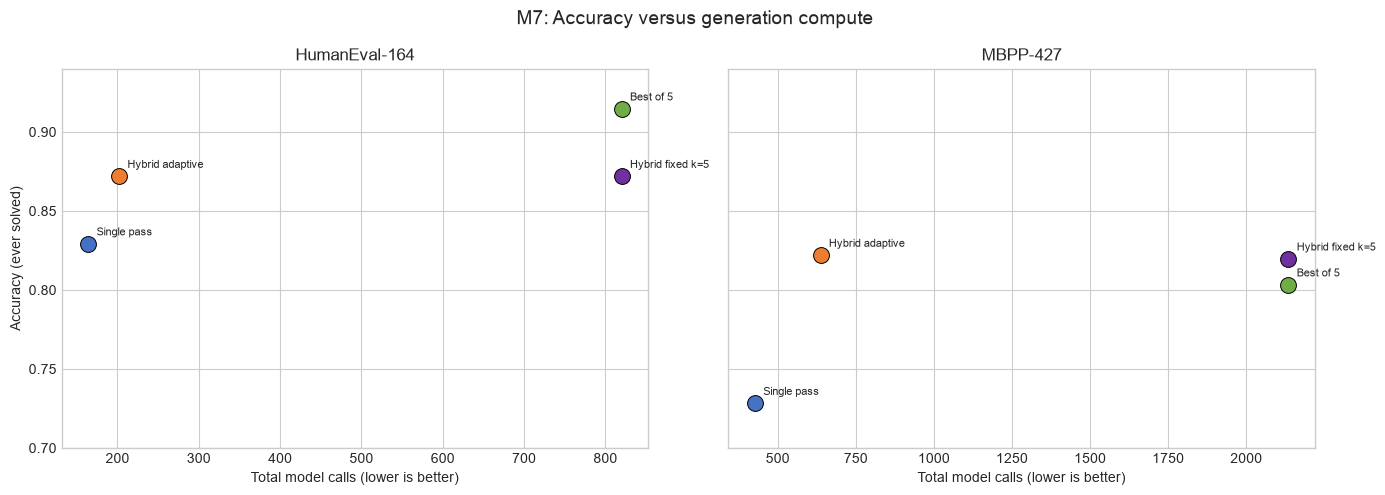

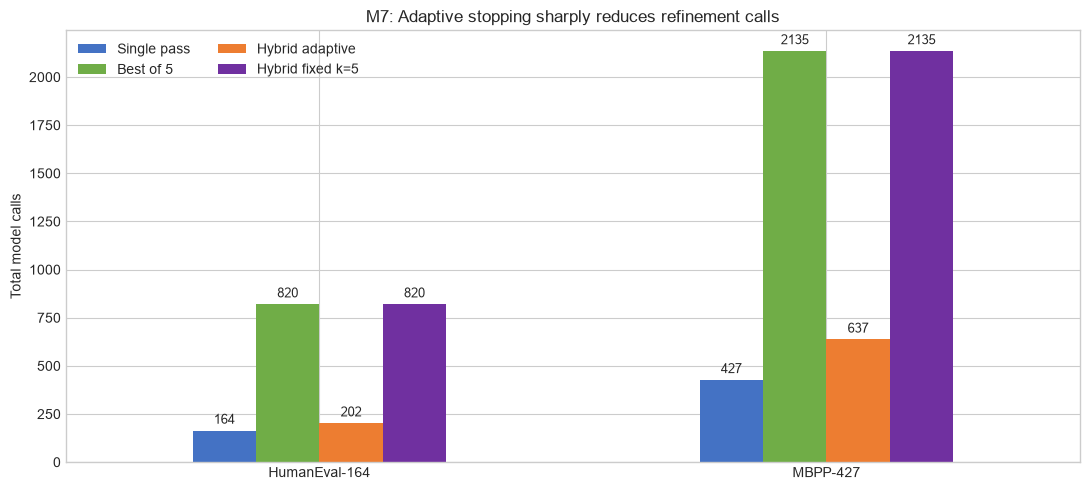

<div style='padding:12px;border-left:5px solid #70AD47;background:#eef8ea'><b>Efficiency:</b> adaptive refinement used <b>202</b> calls on HumanEval versus <b>820</b> for best-of-five, and <b>637</b> versus <b>2135</b> on MBPP. On MBPP it also achieved higher observed accuracy.</div>

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (benchmark, group) in zip(axes, m7_long.groupby("Benchmark", sort=False), strict=True):
    for color, (_, row) in zip(COLORS, group.iterrows(), strict=True):
        ax.scatter(
            row["Model calls"],
            row["Accuracy (ever solved)"],
            s=130,
            color=color,
            edgecolor="black",
            linewidth=0.7,
            label=row["Strategy"],
            zorder=3,
        )
        ax.annotate(
            row["Strategy"],
            (row["Model calls"], row["Accuracy (ever solved)"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_title(benchmark)
    ax.set_xlabel("Total model calls (lower is better)")
    ax.set_ylim(0.70, 0.94)
axes[0].set_ylabel("Accuracy (ever solved)")
fig.suptitle("M7: Accuracy versus generation compute", fontsize=14)
plt.tight_layout()
plt.show()

compute = m7_long.pivot(index="Benchmark", columns="Strategy", values="Model calls")[
    ["Single pass", "Best of 5", "Hybrid adaptive", "Hybrid fixed k=5"]
]
assert compute.loc["HumanEval-164"].to_dict() == {
    "Single pass": 164,
    "Best of 5": 820,
    "Hybrid adaptive": 202,
    "Hybrid fixed k=5": 820,
}
assert compute.loc["MBPP-427"].to_dict() == {
    "Single pass": 427,
    "Best of 5": 2135,
    "Hybrid adaptive": 637,
    "Hybrid fixed k=5": 2135,
}
ax = compute.plot.bar(color=COLORS, figsize=(11, 5))
ax.set_ylabel("Total model calls")
ax.set_xlabel("")
ax.set_title("M7: Adaptive stopping sharply reduces refinement calls")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", ncols=2)
label_bars(ax, digits=0)
plt.tight_layout()
plt.show()

display(Markdown(
    "<div style='padding:12px;border-left:5px solid #70AD47;background:#eef8ea'>"
    f"<b>Efficiency:</b> adaptive refinement used "
    f"<b>{int(compute.loc['HumanEval-164', 'Hybrid adaptive'])}</b> calls on HumanEval "
    f"versus <b>{int(compute.loc['HumanEval-164', 'Best of 5'])}</b> for best-of-five, "
    f"and <b>{int(compute.loc['MBPP-427', 'Hybrid adaptive'])}</b> versus "
    f"<b>{int(compute.loc['MBPP-427', 'Best of 5'])}</b> on MBPP. On MBPP it also "
    "achieved higher observed accuracy.</div>"
))

### M7 paired statistics

The primary comparison is hybrid adaptive refinement against compute-matched best-of-five. Outcomes are aligned by exact task ID and passed to the same M6 exact McNemar implementation. Bootstrap intervals use 10,000 problem-level resamples with seed 42.

The larger samples narrow uncertainty, but they do **not** make either adaptive-refinement difference significant at α=0.05. Statistical significance is determined by the paired discordant counts, not sample size alone.

In [9]:
m7_test_rows = []
m7_ci_rows = []
for benchmark, strategies in M7_RUNS.items():
    _, adaptive, bo5 = load_paired_outcomes(
        strategies["Hybrid adaptive"], strategies["Best of 5"]
    )
    test = mcnemar_exact(adaptive, bo5)
    m7_test_rows.append({
        "Benchmark": benchmark,
        "Comparison": "Hybrid adaptive vs Best of 5",
        "Adaptive only": test.first_only,
        "BO5 only": test.second_only,
        "Risk difference": test.paired_risk_difference,
        "Matched OR": test.matched_odds_ratio,
        "Exact p": test.p_value,
        "Significant (α=0.05)": test.p_value < 0.05,
    })
    for label, outcomes in [("Hybrid adaptive", adaptive), ("Best of 5", bo5)]:
        ci = bootstrap_pass_at_1(outcomes, resamples=10_000, seed=42)
        m7_ci_rows.append({
            "Benchmark": benchmark,
            "Configuration": label,
            "pass@1": ci.estimate,
            "CI lower": ci.lower,
            "CI upper": ci.upper,
        })

    fixed_records = load_records(strategies["Hybrid fixed k=5"])
    fixed_final = tuple(
        record["iterations"][-1]["execution"]["passed"] for record in fixed_records
    )
    bo5_by_id = load_pass_fail_vector(strategies["Best of 5"])
    fixed_final_test = mcnemar_exact(
        fixed_final,
        tuple(bo5_by_id[record["task_id"]] for record in fixed_records),
    )
    m7_test_rows.append({
        "Benchmark": benchmark,
        "Comparison": "Fixed k=5 final-only vs Best of 5",
        "Adaptive only": fixed_final_test.first_only,
        "BO5 only": fixed_final_test.second_only,
        "Risk difference": fixed_final_test.paired_risk_difference,
        "Matched OR": fixed_final_test.matched_odds_ratio,
        "Exact p": fixed_final_test.p_value,
        "Significant (α=0.05)": fixed_final_test.p_value < 0.05,
    })

m7_tests = pd.DataFrame(m7_test_rows)
m7_cis = pd.DataFrame(m7_ci_rows)
display(
    m7_cis.style.format({
        "pass@1": "{:.4f}",
        "CI lower": "{:.4f}",
        "CI upper": "{:.4f}",
    }).set_caption("M7 bootstrap 95% confidence intervals (10,000 resamples)")
)
display(
    m7_tests.style.format({
        "Risk difference": "{:+.4f}",
        "Matched OR": "{:.3f}",
        "Exact p": "{:.4f}",
    }).set_caption("M7 exact two-sided McNemar comparisons")
)

primary = m7_tests[m7_tests["Comparison"] == "Hybrid adaptive vs Best of 5"]
assert not primary["Significant (α=0.05)"].any()
display(Markdown(
    "<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'>"
    "<b>Primary inference:</b> corrected HumanEval adaptive vs BO5 has 3 vs 10 directional "
    "discordances (p=0.0923); MBPP has 25 vs 17 (p=0.2800). Neither observed "
    "difference is statistically significant at α=0.05. The HumanEval fixed-k "
    "final-only diagnostic does differ significantly from BO5 (3 vs 15; p=0.0075), but this "
    "is a secondary convergence-ablation result, not the primary refinement metric.</div>"
))

,Benchmark,Configuration,pass@1,CI lower,CI upper
0,HumanEval-164,Hybrid adaptive,0.8720,0.8171,0.9207
1,HumanEval-164,Best of 5,0.9146,0.8720,0.9512
2,MBPP-427,Hybrid adaptive,0.8220,0.7845,0.8571
3,MBPP-427,Best of 5,0.8033,0.7635,0.8407


,Benchmark,Comparison,Adaptive only,BO5 only,Risk difference,Matched OR,Exact p,Significant (α=0.05)
0,HumanEval-164,Hybrid adaptive vs Best of 5,3,10,-0.0427,0.300,0.0923,False
1,HumanEval-164,Fixed k=5 final-only vs Best of 5,3,15,-0.0732,0.200,0.0075,True
2,MBPP-427,Hybrid adaptive vs Best of 5,25,17,+0.0187,1.471,0.2800,False
3,MBPP-427,Fixed k=5 final-only vs Best of 5,18,24,-0.0141,0.750,0.4408,False


<div style='padding:12px;border-left:5px solid #4472C4;background:#edf4ff'><b>Primary inference:</b> corrected HumanEval adaptive vs BO5 has 3 vs 10 directional discordances (p=0.0923); MBPP has 25 vs 17 (p=0.2800). Neither observed difference is statistically significant at α=0.05. The HumanEval fixed-k final-only diagnostic does differ significantly from BO5 (3 vs 15; p=0.0075), but this is a secondary convergence-ablation result, not the primary refinement metric.</div>

In [10]:
regression_rows = []
for benchmark, regressions in fixed_regressions.items():
    fixed_row = m7_long[
        (m7_long["Benchmark"] == benchmark)
        & (m7_long["Strategy"] == "Hybrid fixed k=5")
    ].iloc[0]
    regression_rows.append({
        "Benchmark": benchmark,
        "Ever-solved accuracy": fixed_row["Accuracy (ever solved)"],
        "Final-only accuracy": fixed_row["Final-only accuracy"],
        "Ever solved but final failed": len(regressions),
        "Affected task IDs": ", ".join(regressions),
    })
regression_table = pd.DataFrame(regression_rows)
display(
    regression_table.style.format({
        "Ever-solved accuracy": "{:.4f}",
        "Final-only accuracy": "{:.4f}",
    }).set_caption("Fixed-k regression after an earlier successful iteration")
)

assert len(fixed_regressions["HumanEval-164"]) == 5
assert len(fixed_regressions["MBPP-427"]) == 13
display(Markdown(
    "<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'>"
    "<b>Why success must stop first:</b> forcing all five iterations left "
    "<b>5 HumanEval</b> and <b>13 MBPP</b> problems failing at iteration 5 even "
    "though an earlier iteration had passed. This directly validates the "
    "success-priority convergence rule.</div>"
))

,Benchmark,Ever-solved accuracy,Final-only accuracy,Ever solved but final failed,Affected task IDs
0,HumanEval-164,0.8720,0.8415,5,"HumanEval/100, HumanEval/134, HumanEval/138, HumanEval/160, HumanEval/81"
1,MBPP-427,0.8197,0.7892,13,"MBPP/143, MBPP/160, MBPP/249, MBPP/265, MBPP/393, MBPP/437, MBPP/446, MBPP/465, MBPP/624, MBPP/722, MBPP/757, MBPP/758, MBPP/809"


<div style='padding:12px;border-left:5px solid #C00000;background:#fff0f0'><b>Why success must stop first:</b> forcing all five iterations left <b>5 HumanEval</b> and <b>13 MBPP</b> problems failing at iteration 5 even though an earlier iteration had passed. This directly validates the success-priority convergence rule.</div>

## Six case studies — where feedback helps and where it fails

In [11]:
case_ids = ["HumanEval/46", "HumanEval/75", "HumanEval/83", "MBPP/446", "MBPP/597", "MBPP/734"]

def outcome_text(record):
    iterations = len(record["iterations"])
    if record["passed"]:
        return f"Solved (iteration {iterations})"
    return f"Unsolved ({record['convergence_reason']}, iteration {iterations})"

case_rows = []
for task_id in case_ids:
    benchmark = "HumanEval-Dev" if task_id.startswith("HumanEval") else "MBPP-Dev"
    records = {key: problem_record(RUNS[key][benchmark], task_id) for key in ("template", "trace", "hybrid")}
    category = records["template"]["iterations"][0]["classification"]["category"].replace("_", " ").title()
    case_rows.append({
        "Case": task_id,
        "Benchmark": benchmark,
        "Initial category": category,
        "Template": outcome_text(records["template"]),
        "Trace": outcome_text(records["trace"]),
        "Hybrid": outcome_text(records["hybrid"]),
    })
case_table = pd.DataFrame(case_rows).set_index("Case")
display(case_table.style.set_caption("Named cases across all M5 feedback strategies").set_properties(**{"text-align": "left"}))

he83 = case_table.loc["HumanEval/83"]
display(Markdown(
    f"<div style='padding:12px;border-left:5px solid #7030A0;background:#f5effa'>"
    f"<b>HumanEval/83 is the clearest warning:</b> template feedback produced <b>{he83['Template']}</b>, while trace produced <b>{he83['Trace']}</b>. More detailed feedback can steer a deterministic model into a worse refinement path.</div>"
))

,Benchmark,Initial category,Template,Trace,Hybrid
Case,,,,,
HumanEval/46,HumanEval-Dev,Logic,"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
HumanEval/75,HumanEval-Dev,Edge Case,Solved (iteration 2),Solved (iteration 2),Solved (iteration 2)
HumanEval/83,HumanEval-Dev,Edge Case,Solved (iteration 2),"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
MBPP/446,MBPP-Dev,Logic,Solved (iteration 2),Solved (iteration 2),Solved (iteration 2)
MBPP/597,MBPP-Dev,Runtime,"Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)","Unsolved (oscillation, iteration 2)"
MBPP/734,MBPP-Dev,Edge Case,"Unsolved (oscillation, iteration 3)",Solved (iteration 2),Solved (iteration 2)


<div style='padding:12px;border-left:5px solid #7030A0;background:#f5effa'><b>HumanEval/83 is the clearest warning:</b> template feedback produced <b>Solved (iteration 2)</b>, while trace produced <b>Unsolved (oscillation, iteration 2)</b>. More detailed feedback can steer a deterministic model into a worse refinement path.</div>

## Historical takeaways through local M7

1. **The cross-benchmark trade-off replicated at full scale.** Adaptive hybrid refinement exceeded best-of-five on corrected MBPP (0.8220 vs 0.8033) while trailing it on HumanEval (0.8720 vs 0.9146). The exact paired tests do not establish either adaptive difference as statistically significant at α=0.05, so these remain strong observed benchmark-specific effects rather than confirmed population-level differences.
2. **Adaptive stopping is the useful efficiency point.** It used 202 versus 820 calls on HumanEval and 637 versus 2,135 on MBPP relative to best-of-five. Fixed-k consumed the same number of calls as best-of-five and could undo correct solutions.
3. **Success-priority convergence is empirically justified.** Five HumanEval and thirteen MBPP problems were ever solved but failed at the final forced iteration. Reporting both ever-solved and final-only diagnostics makes this regression visible.
4. **These are quantized local-development results only.** They are retained as the historical development record; the frozen dissertation results begin in the next section.

## Full-precision Tier 1 — frozen reporting matrix

The cluster replication is complete for all eight Qwen configurations: four methods on HumanEval-164 and the same four on sanitized MBPP-427. The table is rebuilt from the authoritative result directories named in `docs/validation/full_precision_tier1_summary.md`; values are also frozen for dissertation use in `docs/dissertation_results_tables.md`.

The headline fixed-*k* score is **ever solved** (a pass at any permitted iteration). Its iteration-5-only score is a diagnostic. Model calls are counted directly from persisted candidates or iteration records.

,Benchmark,Configuration,pass@1 (ever solved),Solved,Final-only,Model calls
0,HumanEval-164,Single pass,0.8659,142/164,—,164
1,HumanEval-164,Best of 5,0.9268,152/164,—,820
2,HumanEval-164,Hybrid adaptive,0.9024,148/164,—,199
3,HumanEval-164,Hybrid fixed k=5,0.9024,148/164,0.8720,820
4,MBPP-427,Single pass,0.7190,307/427,—,427
5,MBPP-427,Best of 5,0.7892,337/427,—,2135
6,MBPP-427,Hybrid adaptive,0.8244,352/427,—,647
7,MBPP-427,Hybrid fixed k=5,0.8244,352/427,0.7822,2135


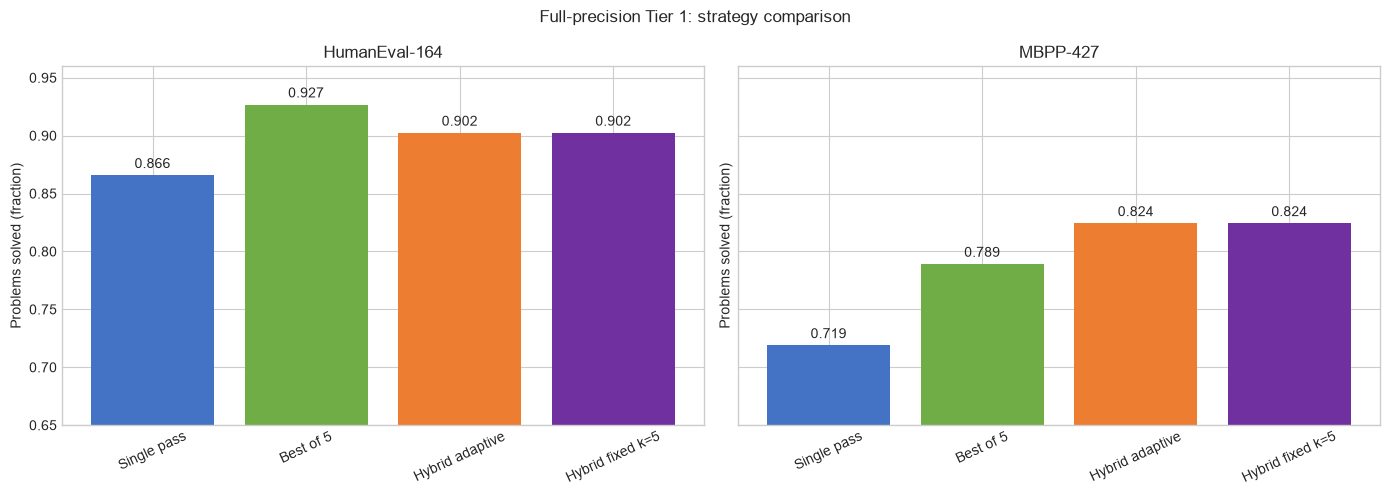

In [12]:
FULL_RUNS = {
    "HumanEval-164": {
        "Single pass": RESULTS / "20260808T204450.467851Z_cluster_qwen_hf_zero_shot_humaneval_full",
        "Best of 5": RESULTS / "20260808T210242.687568Z_cluster_qwen_hf_best_of_5_humaneval_full",
        "Hybrid adaptive": RESULTS / "20260808T215208.948344Z_cluster_qwen_hf_hybrid_refinement_adaptive_humaneval_full",
        "Hybrid fixed k=5": RESULTS / "20260808T220435.152210Z_cluster_qwen_hf_hybrid_refinement_fixed_humaneval_full",
    },
    "MBPP-427": {
        "Single pass": RESULTS / "20260809T100420.122030Z_cluster_qwen_hf_zero_shot_mbpp_full",
        "Best of 5": RESULTS / "20260809T103719.229806Z_cluster_qwen_hf_best_of_5_mbpp_full",
        "Hybrid adaptive": RESULTS / "20260809T155124.955006Z_cluster_qwen_hf_hybrid_refinement_adaptive_mbpp_full",
        "Hybrid fixed k=5": RESULTS / "20260809T162731.848774Z_cluster_qwen_hf_hybrid_refinement_fixed_mbpp_full",
    },
}

full_rows = []
for benchmark, strategies in FULL_RUNS.items():
    for strategy, run in strategies.items():
        assert (run / "summary.csv").is_file(), f"Missing frozen Tier 1 artifact: {run}"
        summary = summary_row(run)
        records = load_records(run)
        calls = sum(len(record.get("candidates", record.get("iterations", [None]))) for record in records)
        final_score = None
        if strategy == "Hybrid fixed k=5":
            final_score = sum(record["iterations"][-1]["execution"]["passed"] for record in records) / len(records)
        full_rows.append({
            "Benchmark": benchmark, "Configuration": strategy,
            "pass@1 (ever solved)": summary["value"],
            "Solved": f"{int(summary['solved'])}/{int(summary['total'])}",
            "Final-only": final_score, "Model calls": calls,
        })
full_tier1 = pd.DataFrame(full_rows)
assert full_tier1["Model calls"].tolist() == [164, 820, 199, 820, 427, 2135, 647, 2135]
display(full_tier1.style.format({"pass@1 (ever solved)": "{:.4f}", "Final-only": lambda x: "—" if pd.isna(x) else f"{x:.4f}"}).set_caption("Frozen full-precision Tier 1 master table"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (benchmark, group) in zip(axes, full_tier1.groupby("Benchmark", sort=False), strict=True):
    bars = ax.bar(group["Configuration"], group["pass@1 (ever solved)"], color=COLORS)
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_title(benchmark); ax.set_ylim(0.65, 0.96); ax.tick_params(axis="x", rotation=25)
    ax.set_ylabel("Problems solved (fraction)")
fig.suptitle("Full-precision Tier 1: strategy comparison")
plt.tight_layout(); plt.show()

## Quantization / backend comparison

Across the four paired configurations, HumanEval consistently favors the full-precision Hugging Face/CUDA setup. MBPP has no consistent direction: full precision loses problems for single-pass and best-of-five, then gains slightly for adaptive and fixed refinement. These are **end-to-end configuration comparisons**, not clean causal estimates of weight precision, because numerical precision, inference backend, hardware, and (for one HumanEval case) execution environment differ together.

The table below recomputes net flips and exact two-sided McNemar tests from the paired per-problem JSON, covering the HumanEval and MBPP single-pass, best-of-five, adaptive, and fixed-*k* comparison documents.

In [13]:
precision_rows = []
for benchmark in FULL_RUNS:
    for strategy in FULL_RUNS[benchmark]:
        _, full_outcomes, q4_outcomes = load_paired_outcomes(FULL_RUNS[benchmark][strategy], M7_RUNS[benchmark][strategy])
        test = mcnemar_exact(full_outcomes, q4_outcomes)
        precision_rows.append({
            "Benchmark": benchmark, "Configuration": strategy,
            "Full-only flips": test.first_only, "Q4-only flips": test.second_only,
            "Net flips (full − Q4)": test.first_only - test.second_only,
            "Difference (pp)": 100 * test.paired_risk_difference,
            "Exact McNemar p": test.p_value,
        })
precision_table = pd.DataFrame(precision_rows)
display(precision_table.style.format({"Difference (pp)": "{:+.2f}", "Exact McNemar p": "{:.4f}"}).set_caption("Observed full-precision/backend difference relative to Q4_K_M/Ollama"))

,Benchmark,Configuration,Full-only flips,Q4-only flips,Net flips (full − Q4),Difference (pp),Exact McNemar p
0,HumanEval-164,Single pass,8,2,6,+3.66,0.1094
1,HumanEval-164,Best of 5,4,2,2,+1.22,0.6875
2,HumanEval-164,Hybrid adaptive,7,2,5,+3.05,0.1797
3,HumanEval-164,Hybrid fixed k=5,7,2,5,+3.05,0.1797
4,MBPP-427,Single pass,8,12,-4,-0.94,0.5034
5,MBPP-427,Best of 5,5,11,-6,-1.41,0.2101
6,MBPP-427,Hybrid adaptive,13,12,1,+0.23,1.0000
7,MBPP-427,Hybrid fixed k=5,13,11,2,+0.47,0.8388


## Forced-iteration regression — root cause and replication

The deep dive identified a concrete mechanism. After a program passed every persisted test, fixed mode correctly recorded `All assertions passed.` but the next prompt immediately demanded `Return a corrected complete solution.` With no failing assertion or traceback to repair, the model performed an **uninformed post-success mutation**. The execution feedback was accurate; the surrounding instruction was self-contradictory.

All 41 observed final-state regressions were logic or edge-case failures. The phenomenon replicated in all four benchmark/configuration conditions. MBPP has more raw regressions in both precision settings; the full-precision rate is also larger, while Q4 rates are nearly equal. This is an emerging benchmark pattern, not yet a causal benchmark effect.

In [14]:
regression_table = pd.DataFrame([
    {"Precision / backend": "Q4_K_M / Ollama", "Benchmark": "HumanEval-164", "Regressions": 5, "Ever solved": 143},
    {"Precision / backend": "Q4_K_M / Ollama", "Benchmark": "MBPP-427", "Regressions": 13, "Ever solved": 350},
    {"Precision / backend": "bfloat16 / Hugging Face", "Benchmark": "HumanEval-164", "Regressions": 5, "Ever solved": 148},
    {"Precision / backend": "bfloat16 / Hugging Face", "Benchmark": "MBPP-427", "Regressions": 18, "Ever solved": 352},
])
regression_table["Regression rate among ever solved"] = regression_table["Regressions"] / regression_table["Ever solved"]
assert regression_table["Regressions"].sum() == 41
display(regression_table.style.format({"Regression rate among ever solved": "{:.1%}"}).set_caption("Four-condition forced-iteration replication"))

,Precision / backend,Benchmark,Regressions,Ever solved,Regression rate among ever solved
0,Q4_K_M / Ollama,HumanEval-164,5,143,3.5%
1,Q4_K_M / Ollama,MBPP-427,13,350,3.7%
2,bfloat16 / Hugging Face,HumanEval-164,5,148,3.4%
3,bfloat16 / Hugging Face,MBPP-427,18,352,5.1%


## Tier 2 — CodeLlama status at 10 August 2026

The committed preliminary run uses `codellama/CodeLlama-13b-Instruct-hf` with bitsandbytes **8-bit quantization** on the 20-problem HumanEval development split. It solved **11/20 (0.5500)**. This is a pipeline/development measurement, not a dissertation reporting result and not directly comparable to Qwen full precision as a model-family claim.

The full HumanEval-164 run is now complete under the same bitsandbytes **8-bit quantized** configuration: **68/164 (`pass@1_single = 0.4146`)**. The artifact contains coherent generated Python rather than corrupted or numerically unstable output. Its failures show systematic instruction-following gaps—such as omitting required typing imports—and ordinary semantic errors, with **no observed quantization artifacts** in the data-quality review.

On that evidence, the 8-bit run was assessed as usable for the Tier 2 cross-family replication, and a both-GPU full-precision rerun was assessed as **unnecessary**. This is an evidence-based scope decision, not a claim that 8-bit and full precision are universally equivalent.

In [15]:
codellama_dev = RESULTS / "20260809T221313.828881Z_cluster_codellama_13b_bnb_8bit_quantized_development_humaneval_dev"
codellama_full = RESULTS / "20260810T113106.471817Z_cluster_codellama_13b_bnb_8bit_zero_shot_humaneval_full"
codellama_row = summary_row(codellama_dev)
codellama_full_row = summary_row(codellama_full)
assert (int(codellama_row["solved"]), int(codellama_row["total"])) == (11, 20)
assert (int(codellama_full_row["solved"]), int(codellama_full_row["total"])) == (68, 164)
assert len(load_records(codellama_full)) == 164
tier2_status = pd.DataFrame([
    {"Scope": "HumanEval-Dev", "Precision": "bitsandbytes 8-bit", "Status": "Complete (preliminary)", "Result": f"{int(codellama_row['solved'])}/{int(codellama_row['total'])} = {codellama_row['value']:.4f}"},
    {"Scope": "HumanEval-164", "Precision": "bitsandbytes 8-bit", "Status": "Complete; quality-assessed", "Result": f"{int(codellama_full_row['solved'])}/{int(codellama_full_row['total'])} = {codellama_full_row['value']:.4f}"},
    {"Scope": "Both-GPU rerun", "Precision": "Full precision", "Status": "Assessed as unnecessary", "Result": "Not run"},
])
display(tier2_status.style.set_caption("CodeLlama evidence boundary"))

,Scope,Precision,Status,Result
0,HumanEval-Dev,bitsandbytes 8-bit,Complete (preliminary),11/20 = 0.5500
1,HumanEval-164,bitsandbytes 8-bit,Complete; quality-assessed,68/164 = 0.4146
2,Both-GPU rerun,Full precision,Assessed as unnecessary,Not run


## Supervisor-meeting summary

### What is established

Tier 1 is complete and frozen: eight full-precision Qwen runs cover HumanEval-164 and sanitized MBPP-427. The central comparison is now evidence-backed on both benchmarks. Adaptive refinement used far fewer calls than best-of-five; it trailed best-of-five by 4 HumanEval problems (148 vs 152, exact McNemar *p*=0.3438), but beat it by 15 MBPP problems (352 vs 337, *p*=0.0489). Fixed continuation found no additional problem beyond adaptive stopping on either benchmark.

### Headline findings to highlight

1. **Execution-guided refinement can beat compute-matched resampling, but the effect is benchmark-dependent.** On MBPP it was both more accurate (+15 problems) and more efficient (647 vs 2,135 calls); on HumanEval it traded lower accuracy for much lower compute (199 vs 820 calls).
2. **Stop on success.** Forced continuation added no ever-solved gains and produced 41 final-state regressions across four conditions because the prompt asked the model to correct already-passing code.
3. **Local quantized measurements are not capability-precise substitutes for reporting runs.** HumanEval consistently favored the full-precision configuration, whereas MBPP changed direction by method; headline claims therefore use the frozen full-precision artifacts.

### Still in progress

Tier 2 cross-family work is underway beyond the now-complete single-pass baseline. CodeLlama-13B at 8-bit quantization solved 68/164 HumanEval problems (0.4146). Data-quality review found coherent code and systematic instruction-following/semantic failures rather than quantization artifacts, so the quantized result was accepted for the Tier 2 replication and the both-GPU full-precision fallback was assessed as unnecessary. The remaining Tier 2 refinement and ablation runs are still in progress.